In [1]:
import os
import sys
from pathlib import Path
import logging
import time

from websocket_server import WebsocketServer
from multiprocessing import Process

import pickle
import json
import pandas as pd
import numpy as np

cur_dir = os.getcwd()
path = Path(cur_dir)
sys.path.insert(0, str(path.parent.absolute()))

from src.preprocess import preprocess_df
from src.real_time_model import NetworkModel
from src.time_windowed import get_window
from src.safe_routing import communication_graph_from_df
from src.stream_data import start_web_socket_server, start_stream

In [9]:
with open(r'saves\victim_net.pickle', 'rb') as handle:
   names = pickle.load(handle) 

len(names)

13

In [4]:
with open(r'saves\connected_84.pickle', 'rb') as handle:
   names = pickle.load(handle) 

len(names)

84

In [22]:


df_raw = pd.read_csv('..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Tuesday-WorkingHours.pcap_ISCX.csv' , header=0, encoding='cp1252')
df = preprocess_df(df_raw, date_col=' Timestamp')

idx = df[' Source IP'].isin(names) & df[' Destination IP'].isin(names)
df = df[idx].copy()
df_temp = df.iloc[:10000,:]

In [23]:
df_temp

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
133451,192.168.10.16-192.168.10.50-137-137-17,192.168.10.50,137,192.168.10.16,137,17,2017-04-07 01:00:00,47,2,0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
133452,192.168.10.12-192.168.10.50-137-137-17,192.168.10.50,137,192.168.10.12,137,17,2017-04-07 01:00:00,3,2,0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
334175,192.168.10.50-192.168.10.51-21-53143-6,192.168.10.51,53143,192.168.10.50,21,6,2017-04-07 01:00:00,51,1,2,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
133516,192.168.10.16-192.168.10.50-58110-139-6,192.168.10.16,58110,192.168.10.50,139,6,2017-04-07 01:00:00,95,3,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
404986,192.168.10.3-192.168.10.5-445-56898-6,192.168.10.5,56898,192.168.10.3,445,6,2017-04-07 01:00:00,91534888,28,24,...,20,15644.0,31186.66682,62424.0,48.0,22900000.0,9215142.945,30000000.0,10700000.0,BENIGN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
393898,192.168.10.3-192.168.10.51-53-9950-17,192.168.10.51,9950,192.168.10.3,53,17,2017-04-07 01:51:00,159,2,2,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
332328,192.168.10.3-192.168.10.17-53-10964-17,192.168.10.17,10964,192.168.10.3,53,17,2017-04-07 01:51:00,174,2,2,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
153197,172.217.10.142-192.168.10.16-443-44558-6,192.168.10.16,44558,172.217.10.142,443,6,2017-04-07 01:51:00,293622,12,11,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
429685,192.168.10.3-192.168.10.17-53-48661-17,192.168.10.17,48661,192.168.10.3,53,17,2017-04-07 01:51:00,23980,2,2,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [29]:
df_test = df_temp.iloc[:15]
df_test

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
133451,192.168.10.16-192.168.10.50-137-137-17,192.168.10.50,137,192.168.10.16,137,17,2017-04-07 01:00:00,47,2,0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
133452,192.168.10.12-192.168.10.50-137-137-17,192.168.10.50,137,192.168.10.12,137,17,2017-04-07 01:00:00,3,2,0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
334175,192.168.10.50-192.168.10.51-21-53143-6,192.168.10.51,53143,192.168.10.50,21,6,2017-04-07 01:00:00,51,1,2,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
133516,192.168.10.16-192.168.10.50-58110-139-6,192.168.10.16,58110,192.168.10.50,139,6,2017-04-07 01:00:00,95,3,1,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
404986,192.168.10.3-192.168.10.5-445-56898-6,192.168.10.5,56898,192.168.10.3,445,6,2017-04-07 01:00:00,91534888,28,24,...,20,15644.0,31186.66682,62424.0,48.0,22900000.0,9215142.945,30000000.0,10700000.0,BENIGN
133017,192.168.10.8-192.168.10.50-53044-22-6,192.168.10.8,53044,192.168.10.50,22,6,2017-04-07 01:00:00,161,2,1,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
133014,192.168.10.8-192.168.10.50-53043-22-6,192.168.10.8,53043,192.168.10.50,22,6,2017-04-07 01:00:00,138,1,1,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
133013,192.168.10.8-192.168.10.50-53043-22-6,192.168.10.8,53043,192.168.10.50,22,6,2017-04-07 01:00:00,1559110,35,42,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
316370,192.168.10.8-192.168.10.50-53043-22-6,192.168.10.50,22,192.168.10.8,53043,6,2017-04-07 01:00:00,1,1,2,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
133012,192.168.10.8-192.168.10.50-53044-22-6,192.168.10.8,53044,192.168.10.50,22,6,2017-04-07 01:00:00,1559423,35,40,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


Conditioning number:  4951.119506731881 
Determinant of F^T*F:  0.0003858326210699624


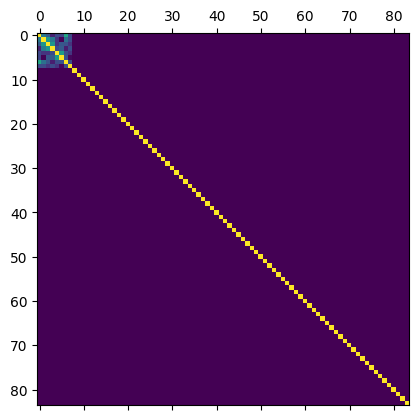

In [34]:
n_entities = len(names)
nm = NetworkModel(entity_names=names, mat_x_init=np.ones(n_entities), mat_p_init=np.eye(n_entities))
nm.update_new_tick(df_test, conn_param='NPR', sync_window_size=0.1, window_type='conn',
                               conn_size=3, keep_unit=True, forget_factor=.6, relief_factor=.6)
mat_x, mat_p, mat_f, window_names = nm.mat_x, nm.mat_p, nm.mat_f, nm.entity_names
plt.matshow(mat_f)

In [35]:
names[:10]

['192.168.10.50',
 '192.168.10.16',
 '192.168.10.12',
 '192.168.10.51',
 '192.168.10.5',
 '192.168.10.3',
 '192.168.10.8',
 '192.168.10.25',
 '192.168.10.19',
 '172.217.12.206']

EdgeView([('192.168.10.50', '192.168.10.16'), ('192.168.10.50', '192.168.10.12'), ('192.168.10.50', '192.168.10.51'), ('192.168.10.50', '192.168.10.8'), ('192.168.10.50', '192.168.10.3'), ('192.168.10.5', '192.168.10.3'), ('192.168.10.3', '192.168.10.25')])

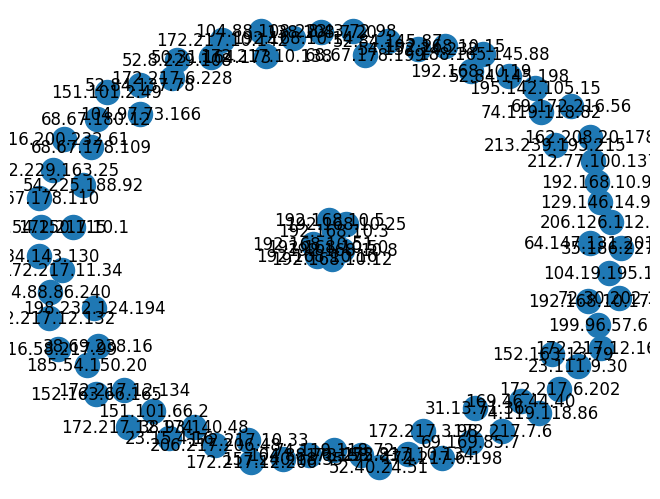

INFO:websocket_server.websocket_server:Client asked to close connection.


In [39]:
g_topo = communication_graph_from_df(df_test, entity_names=names, keep_outsiders=False)
nx.draw(g_topo, with_labels=True)
g_topo.edges

In [5]:
server = start_web_socket_server()

INFO:websocket_server.websocket_server:Listening on port 15674 for clients..
INFO:websocket_server.websocket_server:Starting WebsocketServer on thread Thread-5 (serve_forever).


Starting AMQP Server


In [24]:
import src.network_connectivity, importlib

importlib.reload(src.network_connectivity)
from src.network_connectivity import*

In [25]:
import src.real_time_model, importlib

importlib.reload(src.real_time_model)
from src.real_time_model import*

In [26]:
import src.stream_data, importlib

importlib.reload(src.stream_data)
from src.stream_data import*

In [ ]:
start_stream(server, df, names)

Waiting for Client
Client Connected
Graph #1
                                          Flow ID      Source IP  Source Port  \
133451     192.168.10.16-192.168.10.50-137-137-17  192.168.10.50          137   
133452     192.168.10.12-192.168.10.50-137-137-17  192.168.10.50          137   
334175     192.168.10.50-192.168.10.51-21-53143-6  192.168.10.51        53143   
133516    192.168.10.16-192.168.10.50-58110-139-6  192.168.10.16        58110   
404986      192.168.10.3-192.168.10.5-445-56898-6   192.168.10.5        56898   
133017      192.168.10.8-192.168.10.50-53044-22-6   192.168.10.8        53044   
133014      192.168.10.8-192.168.10.50-53043-22-6   192.168.10.8        53043   
133013      192.168.10.8-192.168.10.50-53043-22-6   192.168.10.8        53043   
316370      192.168.10.8-192.168.10.50-53043-22-6  192.168.10.50           22   
133012      192.168.10.8-192.168.10.50-53044-22-6   192.168.10.8        53044   
133308    192.168.10.3-192.168.10.50-3268-53034-6  192.168.10.50

INFO:websocket_server.websocket_server:Client asked to close connection.


Graph #2
                                          Flow ID       Source IP  \
136081    192.168.10.3-192.168.10.19-3268-44718-6   192.168.10.19   
357976    192.168.10.3-192.168.10.25-3268-54982-6   192.168.10.25   
136076     192.168.10.3-192.168.10.19-389-41387-6   192.168.10.19   
138479       192.168.10.3-192.168.10.5-123-123-17    192.168.10.5   
396422      172.217.12.206-192.168.10.9-80-5277-6  172.217.12.206   
328537     192.168.10.3-192.168.10.15-53-52789-17   192.168.10.15   
348723     192.168.10.3-192.168.10.25-389-54983-6   192.168.10.25   
374307        192.168.10.9-38.69.238.16-5252-80-6    38.69.238.16   
166446     192.168.10.3-192.168.10.25-53-52343-17   192.168.10.25   
133030  192.168.10.50-192.168.10.51-17471-40251-6   192.168.10.51   
133033     192.168.10.50-192.168.10.51-21-53143-6   192.168.10.50   
133028     192.168.10.50-192.168.10.51-21-53143-6   192.168.10.51   
396103      172.217.12.206-192.168.10.9-80-5276-6  172.217.12.206   
133029  192.168.10.50-192

In [10]:
current_datetime, current_datetime.strftime('%X')

(Timestamp('2017-04-07 01:00:00'), '01:00:00')

In [28]:
server.clients



[{'id': 4,
  'handler': <websocket_server.websocket_server.WebSocketHandler at 0x1e84acbcc70>,
  'address': ('127.0.0.1', 53826)}]

INFO:websocket_server.websocket_server:Client asked to close connection.


In [29]:
server.disconnect_clients_gracefully()

In [30]:
server.shutdown_gracefully()

In [10]:
server.shutdown_abruptly()

In [18]:
import src.network_connectivity, importlib

importlib.reload(src.network_connectivity)
from src.network_connectivity import*

In [21]:
del server